# 🛫 Prévision des Retards Aériens — Notebook MLflow
**Projet PPML- FlyOnTime — 6 plus grands aéroports français**

Workflow :
1. Configuration & Imports
2. Connexion MLflow
3. Chargement des données (S3)
4. Analyse Exploratoire (EDA)
5. Nettoyage des données
6. Feature Engineering
7. Préparation pour la modélisation
8. Modélisation & Logging MLflow
9. Optimisation du meilleur modèle
10. Analyse des importances de variables

## 1. Configuration & Imports

In [2]:
# =====================================================================
# IMPORTS GLOBAUX
# Toutes les dépendances centralisées ici
# éparpillés dans le notebook
# =====================================================================

import os
import warnings
import numpy as np
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.base import clone

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

from dotenv import load_dotenv

# Chargement des variables d'environnement (.env)
load_dotenv(override=True)

# Options d'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


## 2. Connexion MLflow

In [3]:
# =====================================================================
# CONFIGURATION MLFLOW
# Serveur distant hébergé sur Hugging Face Spaces
# =====================================================================

#MLFLOW_REMOTE_URI = "https://patjedhahf-mlflow-ppml.hf.space/"
MLFLOW_REMOTE_URI = "https://stoneray-ppml-mlflow.hf.space/"
EXPERIMENT_NAME   = "FlyOntime_RF_classifier"

mlflow.set_tracking_uri(MLFLOW_REMOTE_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ MLflow connecté  : {MLFLOW_REMOTE_URI}")
print(f"   Expérience     : {EXPERIMENT_NAME}")

✅ MLflow connecté  : https://stoneray-ppml-mlflow.hf.space/
   Expérience     : FlyOntime_RF_classifier


## 3. Chargement des données

**Source :** AWS S3 (format Parquet)

**Datasets :**
- `df_train` → données historiques pour l'entraînement
- `df_predict` → données d'avril 2026 pour la prédiction finale

In [4]:
# =====================================================================
# FONCTION DE CHARGEMENT S3 (MISE À JOUR)
# Gère maintenant le CSV et le Parquet intelligemment
# =====================================================================

def get_s3_data(s3_key: str) -> pd.DataFrame:
    """Charge un fichier (Parquet ou CSV) depuis S3."""
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1",
    )
    bucket = os.getenv("BUCKET_EQUIPE") 
    
    # On construit l'URL proprement
    full_path = f"s3://{bucket}/{s3_key}"
    
    print(f"📥 Chargement de : {full_path}")
    
    if s3_key.endswith('.csv'):
        return pd.read_csv(full_path)
    else:
        return pd.read_parquet(full_path)


# --- Chemins S3 ---
S3_TRAIN   = "datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv"
S3_PREDICT = "datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv"

# --- Chargement ---
df_train = get_s3_data(S3_TRAIN)
print(f"✅ df_train   : {df_train.shape[0]:,} lignes | {df_train.shape[1]} colonnes")

df_predict = get_s3_data(S3_PREDICT)
print(f"✅ df_predict : {df_predict.shape[0]:,} lignes | {df_predict.shape[1]} colonnes")

📥 Chargement de : s3://ppml2026/datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv
✅ df_train   : 94,378 lignes | 96 colonnes
📥 Chargement de : s3://ppml2026/datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv
✅ df_predict : 4,063 lignes | 96 colonnes


In [5]:
# Aperçu rapide des colonnes disponibles
print("Colonnes df_train :")
print(df_train.columns.tolist())
df_train.head()

Colonnes df_train :
['flight_date', 'movement_date', 'flight_number', 'airline', 'airport_origin', 'airport_destination', 'terminal_departure', 'terminal_arrival', 'scheduled_departure', 'scheduled_arrival', 'estimated_departure', 'estimated_arrival', 'actual_departure', 'actual_arrival', 'actual_source_departure', 'actual_source_arrival', 'departure_delay_min', 'departure_advance_min', 'arrival_delay_min', 'arrival_advance_min', 'status', 'movement_type', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'cloud_base_dep', 'visibility_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunder

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,estimated_departure,estimated_arrival,actual_departure,actual_arrival,actual_source_departure,actual_source_arrival,departure_delay_min,departure_advance_min,arrival_delay_min,arrival_advance_min,status,movement_type,time_dep,relative_humidity_2m_dep,dew_point_dep,icing_conditions_dep,rain_dep,freezing_rain_dep,snow_dep,thunderstorms_dep,pressure_msl_dep,wind_shear_dep,wind_gusts_10m_dep,wind_speed_10m_dep,wind_direction_10m_dep,precipitation_dep,has_precipitation_dep,fog_dep,humidity_dep,temperature_2m_dep,cloud_cover_dep,cloud_base_dep,visibility_dep,time_arr,relative_humidity_2m_arr,dew_point_arr,icing_conditions_arr,rain_arr,freezing_rain_arr,snow_arr,thunderstorms_arr,pressure_msl_arr,wind_shear_arr,wind_gusts_10m_arr,wind_speed_10m_arr,wind_direction_10m_arr,precipitation_arr,has_precipitation_arr,fog_arr,humidity_arr,temperature_2m_arr,cloud_cover_arr,cloud_base_arr,visibility_arr,Vacances Scolaires,Label des Vacances,Jour férié,Label Jour Ferié,Week End,Vacances PRS,Vacances NCE,Vacances TLS,Vacances MRS,Vacances LYS,is_summer_vacation,GREVE_LYON,LABEL_LYON,GREVE_TOULOUSE,LABEL_TOULOUSE,GREVE_NICE,LABEL_NICE,GREVE_MARSEILLE,LABEL_MARSEILLE,GREVE_CDG,LABEL_CDG,GREVE_ORLY,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,NaN,2025-09-22 00:00+02:00,NaN,2025-09-22 00:00+02:00,NaN,revisedTime,NaN,NaN,50.0,0.0,Arrived,arrival,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-21 21:00:00+00:00,85.0,9.1,Non,0.0,Non,0.0,Non,1019.4,12.54,28.1,14.5,32.0,0.0,Non,Non,85.0,11.6,4.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,NaN,Non,NaN,Non,NaN,Non,NaN,Non,NaN,Non,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,2025-09-21 09:24+02:00,2025-09-21 10:35+02:00,2025-09-21 09:24+02:00,NaN,revisedTime,NaN,9.0,0.0,9.0,NaN,Expected,arrival,2025-09-21 07:00:00+00:00,84.0,11.4,Non,0.0,Non,0.0,Non,1015.8,4.42,11.5,4.2,282.0,0.0,Non,Non,84.0,14.1,100.0,NaN,NaN,2025-09-21 08:00:00+00:00,62.0,15.2,Non,0.2,Non,0.0,Non,1015.7,4.93,22.3,7.6,121.0,0.2,Oui,Non,62.0,22.9,100.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,NaN,Non,NaN,Non,NaN,Non,NaN,Non,NaN,Non,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,2025-09-21 18:09+02:00,NaN,2025-09-21 18:09+02:00,NaN,revisedTime,NaN,109.0,0.0,109.0,NaN,Departed,departure,2025-09-21 14:00:00+00:00,87.0,18.2,Non,0.9,Non,0.0,Non,1013.9,10.48,36.0,13.6,165.0,0.9,Oui,Non,87.0,20.4,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,NaN,Non,NaN,Non,NaN,Non,NaN,Non,NaN,Non,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,2025-09-21 08:13+02:00,2025-09-21 09:08+02:00,2025-09-21 08:13+02:00,2025-09-21 09:08+02:00,revisedTime,revisedTime,13.0,0.0,0.0,7.0,Departed,departure,2025-09-21 06:00:00+00:00,84.0,11.4,Non,0.0,Non,0.0,Non,1015.4,5.82,13.7,6.2,27

In [7]:
# Affiche le type de chaque colonne et le nombre de valeurs non-nulles
print(df_train.info())

# Ou pour une liste plus simple :
print(df_train.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94378 entries, 0 to 94377
Data columns (total 96 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   flight_date                       94378 non-null  object 
 1   movement_date                     94378 non-null  object 
 2   flight_number                     94377 non-null  object 
 3   airline                           94377 non-null  object 
 4   airport_origin                    94377 non-null  object 
 5   airport_destination               94377 non-null  object 
 6   terminal_departure                79760 non-null  object 
 7   terminal_arrival                  80642 non-null  object 
 8   scheduled_departure               93242 non-null  object 
 9   scheduled_arrival                 92834 non-null  object 
 10  estimated_departure               93242 non-null  object 
 11  estimated_arrival                 92834 non-null  object 
 12  actu

In [28]:
df_train.head()

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,estimated_departure,estimated_arrival,actual_departure,actual_arrival,actual_source_departure,actual_source_arrival,departure_delay_min,departure_advance_min,arrival_delay_min,arrival_advance_min,status,movement_type,time_dep,relative_humidity_2m_dep,dew_point_dep,icing_conditions_dep,rain_dep,freezing_rain_dep,snow_dep,thunderstorms_dep,pressure_msl_dep,wind_shear_dep,wind_gusts_10m_dep,wind_speed_10m_dep,wind_direction_10m_dep,precipitation_dep,has_precipitation_dep,fog_dep,humidity_dep,temperature_2m_dep,cloud_cover_dep,time_arr,relative_humidity_2m_arr,dew_point_arr,icing_conditions_arr,rain_arr,freezing_rain_arr,snow_arr,thunderstorms_arr,pressure_msl_arr,wind_shear_arr,wind_gusts_10m_arr,wind_speed_10m_arr,wind_direction_10m_arr,precipitation_arr,has_precipitation_arr,fog_arr,humidity_arr,temperature_2m_arr,cloud_cover_arr,Vacances Scolaires,Label des Vacances,Jour férié,Label Jour Ferié,Week End,Vacances PRS,Vacances NCE,Vacances TLS,Vacances MRS,Vacances LYS,is_summer_vacation,GREVE_LYON,LABEL_LYON,GREVE_TOULOUSE,LABEL_TOULOUSE,GREVE_NICE,LABEL_NICE,GREVE_MARSEILLE,LABEL_MARSEILLE,GREVE_CDG,LABEL_CDG,GREVE_ORLY,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN,0,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,80.0,5.8,NaN,0.0,NaN,0.0,NaN,1016.8,8.51,23.0,10.5,190.0,0.0,NaN,NaN,80.0,9.6,95.0,NaN,79.0,5.9,NaN,0.0,NaN,0.0,NaN,1016.7,8.17,23.8,10.4,191.0,0.0,NaN,NaN,79.0,9.9,96.0,normal_day,normal_day,normal_day,normal_day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal_day,normal_day,normal_day,normal_day,normal_day,normal_day,normal_day,normal_day,normal_day,normal_day,normal_day,normal_day,237.0,245.0,478.0,NaN,350.0,350.0,699.0,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,UNKNOWN,2F,NaN,2025-09-21 23:10+02:00,NaN,2025-09-22 00:00+02:00,0,2025-09-22 00:00+02:00,0,revisedTime,0.0,0.0,50.0,0.0,Arrived,arrival,NaN,80.0,5.8,NaN,0.0,NaN,0.0,NaN,1016.8,8.51,23.0,10.5,190.0,0.0,NaN,NaN,80.0,9.6,95.0,2025-09-21 21:00:00+00:00,85.0,9.1,Non,0.0,Non,0.0,Non,1019.4,12.54,28.1,14.5,32.0,0.0,Non,Non,85.0,11.6,4.0,normal_day,normal_day,0.0,normal_day,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,2025-09-21 09:24+02:00,2025-09-21 10:35+02:00,2025-09-21 09:24+02:00,0,revisedTime,0,9.0,0.0,9.0,0.0,Expected,arrival,2025-09-21 07:00:00+00:00,84.0,11.4,Non,0.0,Non,0.0,Non,1015.8,4.42,11.5,4.2,282.0,0.0,Non,Non,84.0,14.1,100.0,2025-09-21 08:00:00+00:00,62.0,15.2,Non,0.2,Non,0.0,Non,1015.7,4.93,22.3,7.6,121.0,0.2,Oui,Non,62.0,22.9,100.0,normal_day,normal_day,0.0,normal_day,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,UNKNOWN,2025-09-21 16:20+02:00,NaN,2025-09-21 18:09+02:00,NaN,2025-09-21 18:09+02:00,0,revisedTime,0,109.0,0.0,109.0,0.0,Departed,departure,2025-09-21 14:00:00+00:00,87.0,18.2,Non,0.9,Non,0.0,Non,1013.9,10.48,36.0,13.6,165.0,0.9,Oui,Non,87.0,20.4,100.0,NaN,79.0,5.9,NaN,0.0,NaN,0.0,NaN,1016.7,8.17,23.8,10.4,191.0,0.0,NaN,NaN,79.0,9.9,96.0,normal_day,normal_day,0.0,normal_day,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,UNKNOWN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:0

Suppression 1ère ligne inutile

In [ ]:
print(df_train.iloc[0])
df_train = df_train.iloc[1:].reset_index(drop=True)
df_predict = df_predict.iloc[1:].reset_index(drop=True)
display(df_train.head())

flight_date                             DATE_GENERATION
movement_date                       2026-04-17 03:31:48
flight_number                                       NaN
airline                                             NaN
airport_origin                                      NaN
                                           ...         
nombre_departs_destination                        350.0
nombre_arrivees_destination                       350.0
somme_depart_arrivee_destination                  699.0
congestion_destination                              NaN
retard arrivée                                      NaN
Name: 0, Length: 92, dtype: object


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,estimated_departure,estimated_arrival,actual_departure,actual_arrival,actual_source_departure,actual_source_arrival,departure_delay_min,departure_advance_min,arrival_delay_min,arrival_advance_min,status,movement_type,time_dep,relative_humidity_2m_dep,dew_point_dep,icing_conditions_dep,rain_dep,freezing_rain_dep,snow_dep,thunderstorms_dep,pressure_msl_dep,wind_shear_dep,wind_gusts_10m_dep,wind_speed_10m_dep,wind_direction_10m_dep,precipitation_dep,has_precipitation_dep,fog_dep,humidity_dep,temperature_2m_dep,cloud_cover_dep,time_arr,relative_humidity_2m_arr,dew_point_arr,icing_conditions_arr,rain_arr,freezing_rain_arr,snow_arr,thunderstorms_arr,pressure_msl_arr,wind_shear_arr,wind_gusts_10m_arr,wind_speed_10m_arr,wind_direction_10m_arr,precipitation_arr,has_precipitation_arr,fog_arr,humidity_arr,temperature_2m_arr,cloud_cover_arr,Vacances Scolaires,Label des Vacances,Jour férié,Label Jour Ferié,Week End,Vacances PRS,Vacances NCE,Vacances TLS,Vacances MRS,Vacances LYS,is_summer_vacation,GREVE_LYON,LABEL_LYON,GREVE_TOULOUSE,LABEL_TOULOUSE,GREVE_NICE,LABEL_NICE,GREVE_MARSEILLE,LABEL_MARSEILLE,GREVE_CDG,LABEL_CDG,GREVE_ORLY,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,UNKNOWN,2F,NaN,2025-09-21 23:10+02:00,NaN,2025-09-22 00:00+02:00,0,2025-09-22 00:00+02:00,0,revisedTime,0.0,0.0,50.0,0.0,Arrived,arrival,NaN,80.0,5.8,NaN,0.0,NaN,0.0,NaN,1016.8,8.51,23.0,10.5,190.0,0.0,NaN,NaN,80.0,9.6,95.0,2025-09-21 21:00:00+00:00,85.0,9.1,Non,0.0,Non,0.0,Non,1019.4,12.54,28.1,14.5,32.0,0.0,Non,Non,85.0,11.6,4.0,normal_day,normal_day,0.0,normal_day,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
1,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,2025-09-21 09:24+02:00,2025-09-21 10:35+02:00,2025-09-21 09:24+02:00,0,revisedTime,0,9.0,0.0,9.0,0.0,Expected,arrival,2025-09-21 07:00:00+00:00,84.0,11.4,Non,0.0,Non,0.0,Non,1015.8,4.42,11.5,4.2,282.0,0.0,Non,Non,84.0,14.1,100.0,2025-09-21 08:00:00+00:00,62.0,15.2,Non,0.2,Non,0.0,Non,1015.7,4.93,22.3,7.6,121.0,0.2,Oui,Non,62.0,22.9,100.0,normal_day,normal_day,0.0,normal_day,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
2,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,UNKNOWN,2025-09-21 16:20+02:00,NaN,2025-09-21 18:09+02:00,NaN,2025-09-21 18:09+02:00,0,revisedTime,0,109.0,0.0,109.0,0.0,Departed,departure,2025-09-21 14:00:00+00:00,87.0,18.2,Non,0.9,Non,0.0,Non,1013.9,10.48,36.0,13.6,165.0,0.9,Oui,Non,87.0,20.4,100.0,NaN,79.0,5.9,NaN,0.0,NaN,0.0,NaN,1016.7,8.17,23.8,10.4,191.0,0.0,NaN,NaN,79.0,9.9,96.0,normal_day,normal_day,0.0,normal_day,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
3,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,UNKNOWN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,2025-09-21 08:13+02:00,2025-09-21 09:08+02:00,2025-09-21 08:13+02:00,2025-09-21 09:08+02:00,revisedTime,revisedTime,13.0,0.0,0.0,7.0,Departed,departure,2025-09-21 06:00:00+00:00,84.0,11.4,Non,0.0,Non,0.0,Non,1015.4,5.82,13.7,6.2,277.0,0.0,Non,Non,84.0,14.1,100.0,2025-09-21 07:00:00+00:00,86.0,14.1,Non,0.0,Non,0.0,Non,1016.7,4.70,23.0,9.1,321.0,0.0,Non,Non,86.0,16.4,100.0,normal_day,normal_day,0.0,normal_day,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,Non,normal_day,350.0,346.0,6

In [29]:
def nettoyer_dataset(df_input):
    df = df_input.copy()
    
    # --- 1. SUPPRESSION DES COLONNES AVEC TROP DE MANQUES ---
    # Ces colonnes sont vides
    cols_to_drop = [
        'cloud_base_arr', 'visibility_arr', 
        'cloud_base_dep', 'visibility_dep'
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

    # --- 2. TERMINAUX (Remplacement par "UNKNOWN") ---
    cols_terminals = ['terminal_departure', 'terminal_arrival']
    for col in cols_terminals:
        if col in df.columns:
            df[col] = df[col].fillna("UNKNOWN")

    # --- 3. DÉLAIS ET REELS (Remplacement par 0) ---
    # Si la donnée est absente, on considère qu'il n'y a pas eu de retard/avance
    cols_numeric_fill0 = [
        'actual_departure', 'actual_arrival', 'actual_source_departure', 
        'actual_source_arrival', 'departure_delay_min', 'departure_advance_min', 
        'arrival_delay_min', 'arrival_advance_min'
    ]
    for col in cols_numeric_fill0:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # --- 4. ÉVÉNEMENTS & VACANCES (Remplacement par "normal_day") ---
    cols_events = [
        'Vacances Scolaires', 'Label des Vacances', 'Jour férié', 'Label Jour Ferié',
        'LABEL_LYON', 'LABEL_TOULOUSE', 'LABEL_NICE', 'LABEL_MARSEILLE', 'LABEL_CDG', 'LABEL_ORLY',
        'GREVE_LYON', 'GREVE_TOULOUSE', 'GREVE_NICE', 'GREVE_MARSEILLE', 'GREVE_CDG', 'GREVE_ORLY'
    ]
    
    for col in cols_events:
        if col in df.columns:
            # On remplace les NaN par "normal_day"
            df[col] = df[col].fillna("normal_day")
            # Au cas où c'est déjà du texte 'nan', on nettoie aussi
            df[col] = df[col].replace(['nan', 'None', 'NaN', 'null'], "normal_day")

    # --- 5. MÉTÉO (Remplacement par la MÉDIANE) ---
    # On cible les colonnes numériques liées à la météo
    weather_keywords = ['_dep', '_arr', 'temp', 'wind', 'precip', 'cloud', 'humidity']
    weather_cols = [c for c in df.columns if any(key in c.lower() for key in weather_keywords)]
    
    for col in weather_cols:
        if df[col].dtype in [np.float64, np.int64]:
            # On remplace par la médiane de la colonne
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)

    return df

# --- APPLICATION DU NETTOYAGE ---
# On utilise df_train et df_predict qui viennent de tes imports S3
df_train = nettoyer_dataset(df_train)
df_predict = nettoyer_dataset(df_predict)

print("🧹 Nettoyage terminé avec succès !")

🧹 Nettoyage terminé avec succès !


In [20]:
# Affiche le type de chaque colonne et le nombre de valeurs non-nulles
print(df_train.info())

# Ou pour une liste plus simple :
print(df_train.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94378 entries, 0 to 94377
Data columns (total 92 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   flight_date                       94378 non-null  object 
 1   movement_date                     94378 non-null  object 
 2   flight_number                     94377 non-null  object 
 3   airline                           94377 non-null  object 
 4   airport_origin                    94377 non-null  object 
 5   airport_destination               94377 non-null  object 
 6   terminal_departure                94378 non-null  object 
 7   terminal_arrival                  94378 non-null  object 
 8   scheduled_departure               93242 non-null  object 
 9   scheduled_arrival                 92834 non-null  object 
 10  estimated_departure               93242 non-null  object 
 11  estimated_arrival                 92834 non-null  object 
 12  actu

## 4. Analyse Exploratoire (EDA)

### 4.1 Statistiques générales

In [21]:
# =====================================================================
# STATISTIQUES GLOBALES
# =====================================================================

# Dictionnaire ICAO -> Nom  
AEROPORTS_CIBLES = {
    'LFPG': 'Roissy-CDG',
    'LFPO': 'Orly',
    'LFML': 'Marseille',
    'LFMN': 'Nice',
    'LFLL': 'Lyon',
    'LFBO': 'Toulouse' 
}

print(f"Nb total de vols      : {len(df_train):,}")

# On vérifie les aéroports présents dans les destinations
if 'airport_destination' in df_train.columns:
    print(f"Nb aéroports (Dest)   : {df_train['airport_destination'].nunique()}")
    print(f"Nb aéroports (Origine): {df_train['airport_origin'].nunique()}")

# Statistiques sur la colonne de retard (binaire)
print("\n--- Statistiques globales de 'retard arrivée' ---")
if 'retard arrivée' in df_train.columns:
    print(df_train['retard arrivée'].agg(['min', 'mean', 'median', 'max', 'std']).round(2))
else:
    print("⚠️ La colonne 'retard arrivée' est introuvable.")

# Taux de valeurs manquantes
print("\n--- Taux de valeurs manquantes (%) [colonnes > 0%] ---")
# On exclut les colonnes que tu as déjà décidé de laisser vides (comme les labels de vacances)
na_pct = (df_train.isna().sum() / len(df_train) * 100).sort_values(ascending=False)
print(na_pct[na_pct > 0].head(20))

Nb total de vols      : 94,378
Nb aéroports (Dest)   : 6
Nb aéroports (Origine): 6

--- Statistiques globales de 'retard arrivée' ---
min       0.00
mean      0.24
median    0.00
max       1.00
std       0.42
Name: retard arrivée, dtype: float64

--- Taux de valeurs manquantes (%) [colonnes > 0%] ---
scheduled_arrival        1.635974
estimated_arrival        1.635974
thunderstorms_arr        1.635974
time_arr                 1.635974
fog_arr                  1.635974
freezing_rain_arr        1.635974
icing_conditions_arr     1.635974
has_precipitation_arr    1.635974
freezing_rain_dep        1.203670
time_dep                 1.203670
scheduled_departure      1.203670
estimated_departure      1.203670
thunderstorms_dep        1.203670
has_precipitation_dep    1.203670
icing_conditions_dep     1.203670
fog_dep                  1.203670
Vacances LYS             0.001060
is_summer_vacation       0.001060
Vacances MRS             0.001060
Week End                 0.001060
dtype: float64


### 4.2 Répartition par aéroport

In [24]:
# =====================================================================
# ANALYSE PAR AÉROPORT — CODES IATA (CDG, ORY, etc.)
# =====================================================================

# Mise à jour du dictionnaire avec les codes 3 lettres trouvés
AEROPORTS_CIBLES = {
    'CDG': 'Roissy-CDG',
    'ORY': 'Orly',
    'MRS': 'Marseille',
    'NCE': 'Nice',
    'LYS': 'Lyon',
    'TLS': 'Toulouse'
}

# Filtrage (on utilise les nouvelles clés IATA)
df_5 = df_train[df_train['airport_destination'].isin(AEROPORTS_CIBLES.keys())].copy()

# 1. Nombre de vols par aéroport
print(f"--- Répartition sur {len(df_5):,} vols cibles ---")
comptage = df_5['airport_destination'].value_counts()
for code, nom in AEROPORTS_CIBLES.items():
    print(f"  {nom:15s} ({code}) : {comptage.get(code, 0):>7,} vols")

# 2. Statistiques du taux de retard (Classification)
print("\n--- Classement par Taux de Retard ---")
stats_aero = (
    df_5.groupby('airport_destination')['retard arrivée']
    .agg(['count', 'mean'])
)

# Transformation en pourcentage et renommage
stats_aero['mean'] = (stats_aero['mean'] * 100).round(2)
stats_aero.columns = ['Nb Vols', '% de Retard']
stats_aero.index = stats_aero.index.map(AEROPORTS_CIBLES)

print(stats_aero.sort_values('% de Retard', ascending=False))

--- Répartition sur 94,377 vols cibles ---
  Roissy-CDG      (CDG) :  40,577 vols
  Orly            (ORY) :   7,518 vols
  Marseille       (MRS) :   9,616 vols
  Nice            (NCE) :  13,037 vols
  Lyon            (LYS) :  11,580 vols
  Toulouse        (TLS) :  12,049 vols

--- Classement par Taux de Retard ---
                     Nb Vols  % de Retard
airport_destination                      
Nice                   13037        43.97
Marseille               9616        36.69
Toulouse               12049        29.94
Lyon                   11580        21.89
Roissy-CDG             40577        14.51
Orly                    7518        12.58


### 4.3 Retard moyen par tranche horaire

In [25]:
# =====================================================================
# ANALYSE TEMPORELLE (TAUX DE RETARD PAR TRANCHE)
# =====================================================================

# 1. On utilise 'time_dep' qui est l'heure de départ prévue/réelle
# On s'assure que c'est bien au format datetime
df_5['time_dep'] = pd.to_datetime(df_5['time_dep'])
df_5['scheduled_hour'] = df_5['time_dep'].dt.hour

def format_tranche(h, width=3):
    """Génère une étiquette de tranche horaire (ex: '06h-09h')."""
    if pd.isna(h): return "Inconnu"
    debut = int((h // width) * width)
    return f"{debut:02d}h-{debut + width:02d}h"

# Application de la tranche
df_5['tranche_3h'] = df_5['scheduled_hour'].apply(lambda h: format_tranche(h, 3))

# 2. Calcul du TAUX de retard (moyenne des 0 et 1)
# On multiplie par 100 pour avoir un pourcentage lisible
retard_temporel = (
    df_5.groupby('tranche_3h')['retard arrivée']
    .mean().reset_index()
)
retard_temporel['retard arrivée'] = (retard_temporel['retard arrivée'] * 100).round(2)
retard_temporel.columns = ['Tranche Horaire', '% de Vols en Retard']

print("--- Risque de retard par moment de la journée ---")
print(retard_temporel.sort_values('Tranche Horaire').to_string(index=False))

--- Risque de retard par moment de la journée ---
Tranche Horaire  % de Vols en Retard
        00h-03h                 1.61
        03h-06h                 9.21
        06h-09h                21.58
        09h-12h                25.85
        12h-15h                29.89
        15h-18h                21.84
        18h-21h                29.02
        21h-24h                 2.45
        Inconnu                13.30


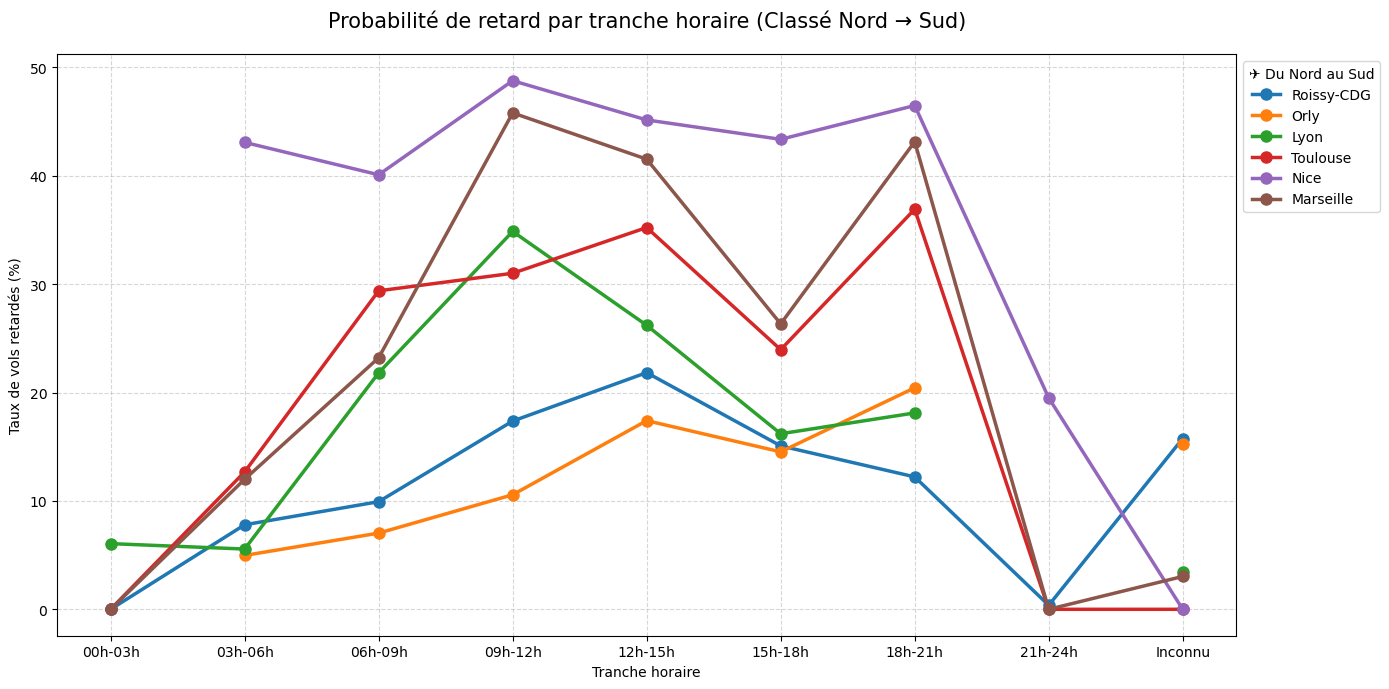

In [26]:
# =====================================================================
# VISUALISATION 
# =====================================================================

# 1. On définit l'ordre géographique (Latitude décroissante)
ORDRE_NORD_SUD = [
    'Roissy-CDG',   # 49.0° N
    'Orly',         # 48.7° N
    'Lyon',         # 45.7° N
    'Toulouse',     # 43.6° N
    'Nice',         # 43.6° N 
    'Marseille'     # 43.4° N
]

# 2. Création de la table pivot
pivot_3h = df_5.pivot_table(
    values='retard arrivée', 
    index='tranche_3h', 
    columns='airport_destination', 
    aggfunc='mean'
)

# 3. Préparation des données (IATA -> Noms + % )
pivot_3h.columns = pivot_3h.columns.map(AEROPORTS_CIBLES)
pivot_3h = (pivot_3h * 100).round(2)

# 4. LE TRUC : On réorganise les colonnes selon notre liste géographique
# On ne garde que les aéroports qui sont présents dans le dataset
colonnes_presentes = [aero for aero in ORDRE_NORD_SUD if aero in pivot_3h.columns]
pivot_3h = pivot_3h[colonnes_presentes]

# 5. Tracé
fig, ax = plt.subplots(figsize=(14, 7))

# La légende suivra automatiquement l'ordre des colonnes de pivot_3h
for aeroport in pivot_3h.columns:
    ax.plot(pivot_3h.index, pivot_3h[aeroport], 
            marker='o', linewidth=2.5, markersize=8, label=aeroport)

ax.set_title("Probabilité de retard par tranche horaire (Classé Nord → Sud)", fontsize=15, pad=20)
ax.set_ylabel("Taux de vols retardés (%)")
ax.set_xlabel("Tranche horaire")
ax.legend(title="✈️ Du Nord au Sud", loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
# =====================================================================
# PRODUCTIVITÉ PAR PISTE — Indicateur de saturation opérationnelle
# =====================================================================

# 1. Configuration des infrastructures (Codes IATA)
# Sources : Données techniques aéroports 2026
INFRA_DATA = {
    'CDG': {'nom': 'Roissy-CDG', 'pistes': 4},
    'ORY': {'nom': 'Orly',       'pistes': 3},
    'MRS': {'nom': 'Marseille',  'pistes': 2},
    'NCE': {'nom': 'Nice',       'pistes': 2},
    'LYS': {'nom': 'Lyon',       'pistes': 2},
    'TLS': {'nom': 'Toulouse',   'pistes': 2},
}

# 2. Préparation de la date pour le calcul quotidien
# On utilise 'time_dep' (ou 'flight_date') pour grouper par jour
df_5['just_date'] = pd.to_datetime(df_5['time_dep']).dt.date

# 3. Calcul de la moyenne de vols par jour et par aéroport
vols_par_jour = df_5.groupby(['airport_destination', 'just_date']).size().reset_index(name='nb_vols')
moy_quotidienne = vols_par_jour.groupby('airport_destination')['nb_vols'].mean()

# 4. Calcul de l'indicateur de saturation
resultats_prod = []
for iata, moy in moy_quotidienne.items():
    if iata in INFRA_DATA:
        nb_pistes = INFRA_DATA[iata]['pistes']
        resultats_prod.append({
            'Aéroport': INFRA_DATA[iata]['nom'],
            'Code': iata,
            'Vols/Jour (Moy)': round(moy, 1),
            'Nb Pistes': nb_pistes,
            'Saturation (Vols/Piste)': round(moy / nb_pistes, 2),
        })

# 5. Création du DataFrame final
df_prod = pd.DataFrame(resultats_prod).sort_values('Saturation (Vols/Piste)', ascending=False)

print("--- Analyse de la Saturation des Pistes ---")
print(df_prod.to_string(index=False))


--- Analyse de la Saturation des Pistes ---
  Aéroport Code  Vols/Jour (Moy)  Nb Pistes  Saturation (Vols/Piste)
Roissy-CDG  CDG            190.1          4                    47.53
      Nice  NCE             63.9          2                    31.94
  Toulouse  TLS             58.8          2                    29.41
      Lyon  LYS             54.8          2                    27.42
 Marseille  MRS             47.0          2                    23.49
      Orly  ORY             36.4          3                    12.15


## 6. Feature Engineering

**Variables créées :**
- `flight_key` : identifiant par rotation (ex: `AF_7313`)
- `airline_group` : regroupement des compagnies rares (<800 vols) → `OTHER`
- Features historiques : retard moyen par compagnie, par vol, par heure
- Encodage cyclique : `hour_sin/cos`, `dow_sin/cos`
- `time_period` : catégorie de moment de la journée
- `weather_index` : indice météo composite normalisé
- `is_delayed_15` : cible binaire (retard > 15 min)

In [ ]:
import numpy as np
import pandas as pd

# =====================================================================
# FEATURE ENGINEERING — PIPELINE ADAPTÉ (CLASSIFICATION)
# =====================================================================

df_fe = df_train.copy()

# ===================================================================
# A. Features COMPAGNIE & INFRASTRUCTURE
# ===================================================================

# 1. Regroupement des compagnies rares
freq_comp = df_fe['airline'].value_counts()
compagnies_rares = freq_comp[freq_comp < 500].index
df_fe['airline_group'] = df_fe['airline'].where(~df_fe['airline'].isin(compagnies_rares), 'OTHER')

# # 2. Intégration de la Saturation Aéroportuaire (Indicateur Expert)
# INFRA_Pistes = {'CDG': 4, 'ORY': 3, 'MRS': 2, 'NCE': 2, 'LYS': 2, 'TLS': 2}
# df_fe['nb_pistes'] = df_fe['airport_destination'].map(INFRA_Pistes).fillna(2)

# On calcule le volume quotidien de l'aéroport pour cette ligne - Analyse de congestion
df_fe['vols_jour_Aero'] = df_fe.groupby(['airport_destination', 'flight_date'])['airline'].transform('count')
#df_fe['saturation_index'] = df_fe['vols_jour_Aero'] / df_fe['nb_pistes']

# 3. Target Encoding (Statistiques historiques)
# On calcule le taux de retard moyen par compagnie et par destination
df_fe['avg_retard_airline'] = df_fe.groupby('airline_group')['retard arrivée'].transform('mean')
df_fe['avg_retard_dest']    = df_fe.groupby('airport_destination')['retard arrivée'].transform('mean')

# ===================================================================
# B. Features TEMPORELLES (Conversion de time_dep)
# ===================================================================

df_fe['time_dep'] = pd.to_datetime(df_fe['time_dep'])

df_fe['hour']        = df_fe['time_dep'].dt.hour
df_fe['dayofweek']   = df_fe['time_dep'].dt.dayofweek
df_fe['month']       = df_fe['time_dep'].dt.month

# Encodage cyclique (essentiel pour capturer que 23h est proche de 00h)
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
df_fe['dow_sin']  = np.sin(2 * np.pi * df_fe['dayofweek'] / 7)
df_fe['dow_cos']  = np.cos(2 * np.pi * df_fe['dayofweek'] / 7)

# Périodes de la journée
def get_time_period(h):
    if 5 <= h < 10: return 'MATIN_PIC'
    if 10 <= h < 16: return 'JOURNEE'
    if 16 <= h < 21: return 'SOIR_PIC'
    return 'NUIT'

df_fe['time_period'] = df_fe['hour'].apply(get_time_period)

# ===================================================================
# C. Features MÉTÉO (Indices Composites)
# ===================================================================

# On crée un indice de sévérité météo pour le départ et l'arrivée
# Plus l'indice est haut, plus le risque est grand
for suffix in ['_dep', '_arr']:
    wind = f'wind_speed_10m{suffix}'
    precip = f'precipitation{suffix}'
    clouds = f'cloud_cover{suffix}'
    
    # Normalisation simple (Min-Max approximatif)
    df_fe[f'weather_score{suffix}'] = (
        (df_fe[wind] / 50) + (df_fe[precip] / 10) + (df_fe[clouds] / 100)
    ) / 3

# ===================================================================
# D. Nettoyage final avant Machine Learning
# ===================================================================

# Colonnes à supprimer car elles sont soit :
# 1. Transformées (dates) 2. Inutiles (noms) 3. Risque de Leakage
COLS_TO_DROP = [
    'flight_date', 'movement_date', 'time_dep', 'time_arr',
    'airline', 'airport_origin', 'actual_source_departure', 
    'actual_source_arrival', 'arrival_delay_min', 'status'
]

df_final = df_fe.drop(columns=COLS_TO_DROP, errors='ignore')

# On transforme les variables texte restantes en dummies (One-Hot)
df_final = pd.get_dummies(df_final, columns=['airport_destination', 'airline_group', 'time_period', 'Label des Vacances'], drop_first=True)

print(f"✅ Feature Engineering terminé !")
print(f"📊 Dataset prêt pour le Random Forest : {df_final.shape[1]} variables.")

✅ Feature Engineering terminé !
📊 Dataset prêt pour le Random Forest : 129 variables.


## 7. Préparation finale pour la modélisation

In [15]:
# =====================================================================
# SÉLECTION DES FEATURES FINALES 
# =====================================================================

# 1. On définit les colonnes numériques (Celles qui sont déjà des chiffres)
FEATURES_NUM = [
    # Météo (Scores composites qu'on a créés)
    'weather_score_dep', 'weather_score_arr',
    
    # Météo brute (Optionnel, le modèle peut y trouver des détails)
    'temperature_2m_arr', 'wind_speed_10m_arr', 'precipitation_arr', 'pressure_msl_arr',
    
    # Temporel cyclique (Le coeur du réacteur)
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'month', 'dayofweek',
    
    # Métier & Saturation (Tes variables "Major de Promo")
    'saturation_index', 'vols_jour_Aero',
    'avg_retard_airline', 'avg_retard_dest',
    
    # Drapeaux binaires (Déjà en 0/1)
    'Jour férié', 'is_summer_vacation', 'GREVE_CDG', 'GREVE_ORLY'
]

# 2. On définit les colonnes qui ont été transformées en "Dummies" (0/1)
# On va chercher toutes les colonnes créées par pd.get_dummies
FEATURES_DUMMIES = [col for col in df_final.columns if 
                    'airport_destination_' in col or 
                    'airline_group_' in col or 
                    'time_period_' in col or 
                    'Label des Vacances_' in col]

# 3. Constitution du dataset d'entraînement (X) et de la cible (y)
# On s'assure de ne prendre que ce qui existe réellement dans df_final
all_features = [f for f in FEATURES_NUM if f in df_final.columns] + FEATURES_DUMMIES

X = df_final[all_features]
y = df_final['retard arrivée']  # Notre cible 0/1

# 4. Affichage du bilan
print(f"✅ Sélection terminée.")
print(f"   - Variables numériques : {len([f for f in FEATURES_NUM if f in df_final.columns])}")
print(f"   - Variables Dummies    : {len(FEATURES_DUMMIES)}")
print(f"   - TOTAL variables (X)  : {X.shape[1]}")
print(f"   - Taille du dataset    : {X.shape[0]:,} lignes")

print("\n📊 Équilibre de la cible (y) :")
print(y.value_counts(normalize=True).map(lambda n: f"{n:.1%}") )

✅ Sélection terminée.
   - Variables numériques : 20
   - Variables Dummies    : 33
   - TOTAL variables (X)  : 53
   - Taille du dataset    : 88,066 lignes

📊 Équilibre de la cible (y) :
retard arrivée
0.0    76.2%
1.0    23.8%
Name: proportion, dtype: object


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# =====================================================================
# SPLIT TRAIN / TEST — OPTIMISÉ CLASSIFICATION
# =====================================================================

# 1. Le Split avec 'stratify'
# IMPORTANT : stratify=y garantit que tu as bien 24% de retards dans le train 
# ET 24% dans le test. Sinon, le hasard pourrait te donner un test sans aucun retard !
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y,   # <-- L'arme secrète pour les datasets déséquilibrés
    shuffle=True
)

print(f"✅ Split terminé :")
print(f"   - Entraînement : {X_train.shape[0]:,} lignes")
print(f"   - Test         : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")

# 2. Configuration du Préprocesseur
# Puisque tu as déjà fait le One-Hot Encoding avec pd.get_dummies, 
# tes variables catégorielles sont déjà des 0 et des 1 (Dummies).
# On ne va donc scaler que les variables NUMÉRIQUES pures.

# On récupère la liste des colonnes numériques réelles présentes dans X
num_to_scale = [f for f in FEATURES_NUM if f in X.columns]

preprocessor = ColumnTransformer([
    # On centre et on réduit les variables météo, saturation, etc.
    ('scaler', StandardScaler(), num_to_scale)
], remainder='passthrough') # 'passthrough' laisse les Dummies (0/1) intacts

print(f"\n✅ Préprocesseur configuré pour {len(num_to_scale)} variables numériques.")
print(f"   Les autres variables (Dummies) resteront inchangées.")

✅ Split terminé :
   - Entraînement : 70,452 lignes
   - Test         : 17,614 lignes (20%)

✅ Préprocesseur configuré pour 20 variables numériques.
   Les autres variables (Dummies) resteront inchangées.


## 8. Modélisation & Logging MLflow

| # | Modèle | Intérêt |
|---|--------|---------|
| 1 | **LinearRegression** | Baseline pure, interprétable |
| 2 | **Ridge (L2)** | Contrôle la multicolinéarité |
| 3 | **Lasso (L1)** | Sélection de features implicite |
| 4 | **RandomForest** | Non-linéaire, robuste aux outliers |

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from mlflow.models import infer_signature

# =====================================================================
# FONCTION DE LOGGING MLFLOW — VERSION CLASSIFICATION
# =====================================================================

def log_model_to_mlflow(pipeline, model_name: str, X_test, y_test,
                         extra_params: dict = None) -> dict:
    """Evalue un pipeline de classification et log les résultats dans MLflow.

    Args:
        pipeline     : Pipeline sklearn (contenant le preprocessor et le classifier)
        model_name   : Nom du run dans MLflow
        X_test       : Features de test (DataFrame avec tes 112 colonnes)
        y_test       : Cible de test (0 ou 1)
        extra_params : Hyperparamètres à logger (ex: n_estimators, max_depth)

    Returns:
        dict avec accuracy, precision, recall, f1
    """
    with mlflow.start_run(run_name=f" {model_name}_Ludo"):
        # 1. Prédictions
        preds = pipeline.predict(X_test)

        # 2. Calcul des métriques de classification
        acc  = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec  = recall_score(y_test, preds)
        f1   = f1_score(y_test, preds)

        # 3. Logging des métriques dans MLflow
        mlflow.log_metric("accuracy",  acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall",    rec)
        mlflow.log_metric("f1_score",  f1)

        # 4. Hyperparamètres
        if extra_params:
            mlflow.log_params(extra_params)

        # 5. Signature et Sauvegarde du modèle
        # La signature permet à MLflow de savoir quel type de données le modèle attend en entrée
        signature = infer_signature(X_test, preds)
        mlflow.sklearn.log_model(pipeline, "model", signature=signature)

        # 6. Tags pour l'organisation
        mlflow.set_tag("projet",    "ppml-retards-avion",   "ludo")
        mlflow.set_tag("type",      "classification_binaire",  "ludo")
        # On log la liste des aéroports cibles (IATA)
        mlflow.set_tag("aeroports", ",".join(AEROPORTS_CIBLES.keys()))

        # Affichage console pour ton suivi
        print(f"✅ {model_name:30s} | F1: {f1:.4f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

    return {'model': model_name, 'f1': f1, 'accuracy': acc, 'precision': prec, 'recall': rec}

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.pipeline import Pipeline

# =====================================================================
# ENTRAÎNEMENT DES 4 MODÈLES BASELINE (VERSION CLASSIFICATION)
# =====================================================================

mlflow.set_experiment(EXPERIMENT_NAME)

# Configuration des pipelines de Classification
models_config = [
    {
        'name': '1_Logistic_Base',
        'pipeline': Pipeline([('pre', clone(preprocessor)), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
        'params': {'model': 'Logistic', 'penalty': 'l2', 'class_weight': 'balanced'}
    },
    {
        'name': '2_Logistic_Lasso',
        'pipeline': Pipeline([('pre', clone(preprocessor)), ('clf', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))]),
        'params': {'model': 'Logistic', 'penalty': 'l1', 'class_weight': 'balanced'}
    },
    {
        'name': '3_RandomForest_Light',
        'pipeline': Pipeline([
            ('pre', clone(preprocessor)), 
            ('clf', RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42, class_weight='balanced'))
        ]),
        'params': {'n_estimators': 50, 'max_depth': 10, 'class_weight': 'balanced'}
    },
    {
        'name': '4_RandomForest_Deep',
        'pipeline': Pipeline([
            ('pre', clone(preprocessor)), 
            ('clf', RandomForestClassifier(n_estimators=150, max_depth=25, n_jobs=-1, random_state=42, class_weight='balanced'))
        ]),
        'params': {'n_estimators': 150, 'max_depth': 25, 'class_weight': 'balanced'}
    },
]

# Entraînement et logging en boucle
results = []
print(f"{'Modèle (Auteur: Ludo)':35s} | {'F1-Score':>8} | {'Accuracy':>8} | {'Recall':>8}")
print("-" * 75)

for cfg in models_config:
    # 1. Entraînement
    cfg['pipeline'].fit(X_train, y_train)
    
    # 2. Évaluation et Logging MLflow (ta fonction avec _Ludo est appelée ici)
    res = log_model_to_mlflow(
        pipeline=cfg['pipeline'],
        model_name=cfg['name'],
        X_test=X_test,
        y_test=y_test,
        extra_params=cfg['params']
    )
    results.append(res)

print(f"\n🎉 Terminé ! Ludo, tu peux aller voir les courbes sur MLflow : {MLFLOW_REMOTE_URI}")

Modèle (Auteur: Ludo)               | F1-Score | Accuracy |   Recall
---------------------------------------------------------------------------


2026/04/17 09:54:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 09:54:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 1_Logistic_Base                | F1: 0.4922 | Acc: 0.6690 | Prec: 0.3879 | Rec: 0.6731
🏃 View run  1_Logistic_Base_Ludo at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7/runs/d723a64221524f3a85e021d64650f0c4
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7


2026/04/17 09:55:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 09:55:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 2_Logistic_Lasso               | F1: 0.4917 | Acc: 0.6687 | Prec: 0.3875 | Rec: 0.6726
🏃 View run  2_Logistic_Lasso_Ludo at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7/runs/708c33ff29794457876ba23f5990dc4d
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7


2026/04/17 09:56:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 09:56:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 3_RandomForest_Light           | F1: 0.6052 | Acc: 0.7568 | Prec: 0.4935 | Rec: 0.7822
🏃 View run  3_RandomForest_Light_Ludo at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7/runs/6a686e2f494247388a9dd7e74f09ea25
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7


2026/04/17 09:56:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 09:56:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 4_RandomForest_Deep            | F1: 0.8691 | Acc: 0.9407 | Prec: 0.9165 | Rec: 0.8263
🏃 View run  4_RandomForest_Deep_Ludo at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7/runs/29d24c68dc36455a88b37108818511e0
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/7

🎉 Terminé ! Ludo, tu peux aller voir les courbes sur MLflow : https://stoneray-ppml-mlflow.hf.space/


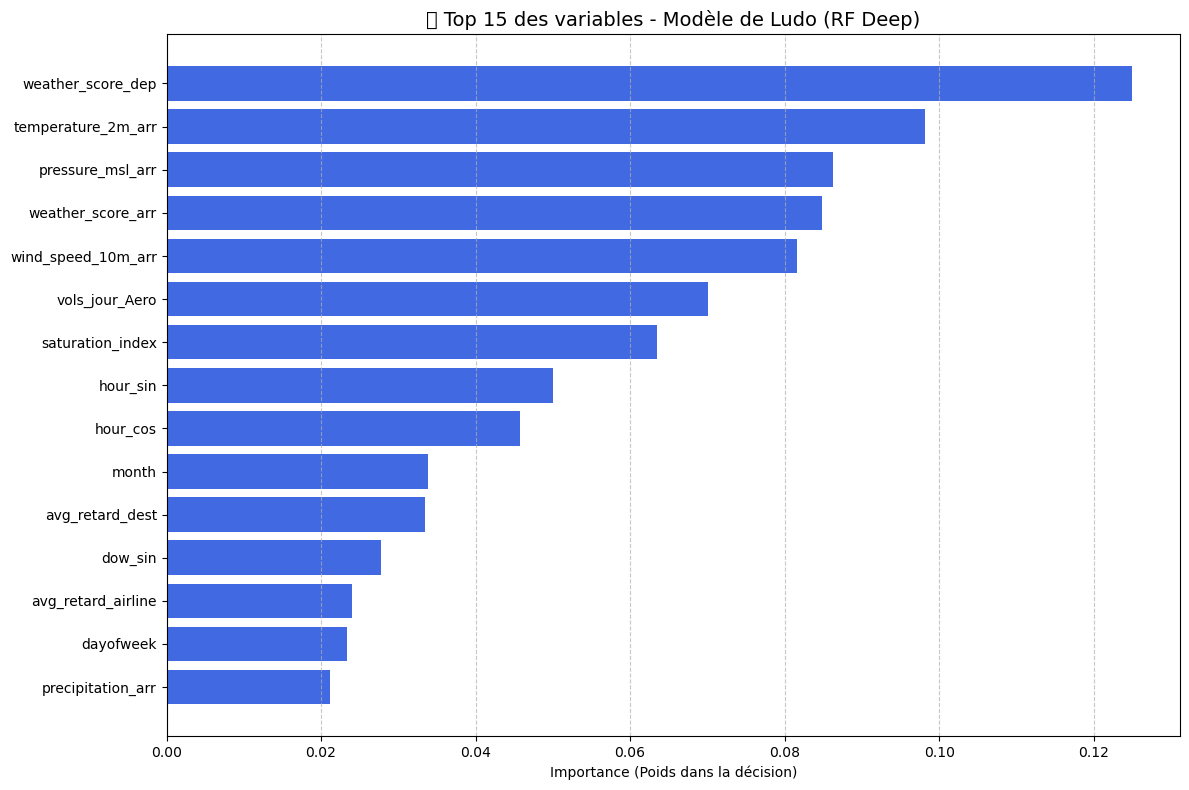

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. On récupère le pipeline du modèle n°4 (index 3 dans la liste)
# C'est celui qui a fait le score de 0.86 !
best_pipeline = models_config[3]['pipeline']

# 2. Extraction des importances depuis l'étape 'clf' (le classifier)
importances = best_pipeline.named_steps['clf'].feature_importances_

# 3. On utilise les noms de colonnes qu'on a défini pour X
feature_names = all_features

# 4. Création du DataFrame pour le tri
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(15)

# 5. Affichage du graphique
plt.figure(figsize=(12, 8))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='royalblue')
plt.gca().invert_yaxis()
plt.title("🔥 Top 15 des variables - Modèle de Ludo (RF Deep)", fontsize=14)
plt.xlabel("Importance (Poids dans la décision)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 8.1 Comparaison des performances

--- Classement des modèles (F1-Score décroissant — meilleur en haut) ---
                          f1  accuracy  precision  recall
model                                                    
4_RandomForest_Deep   0.8691    0.9407     0.9165  0.8263
3_RandomForest_Light  0.6052    0.7568     0.4935  0.7822
1_Logistic_Base       0.4922    0.6690     0.3879  0.6731
2_Logistic_Lasso      0.4917    0.6687     0.3875  0.6726


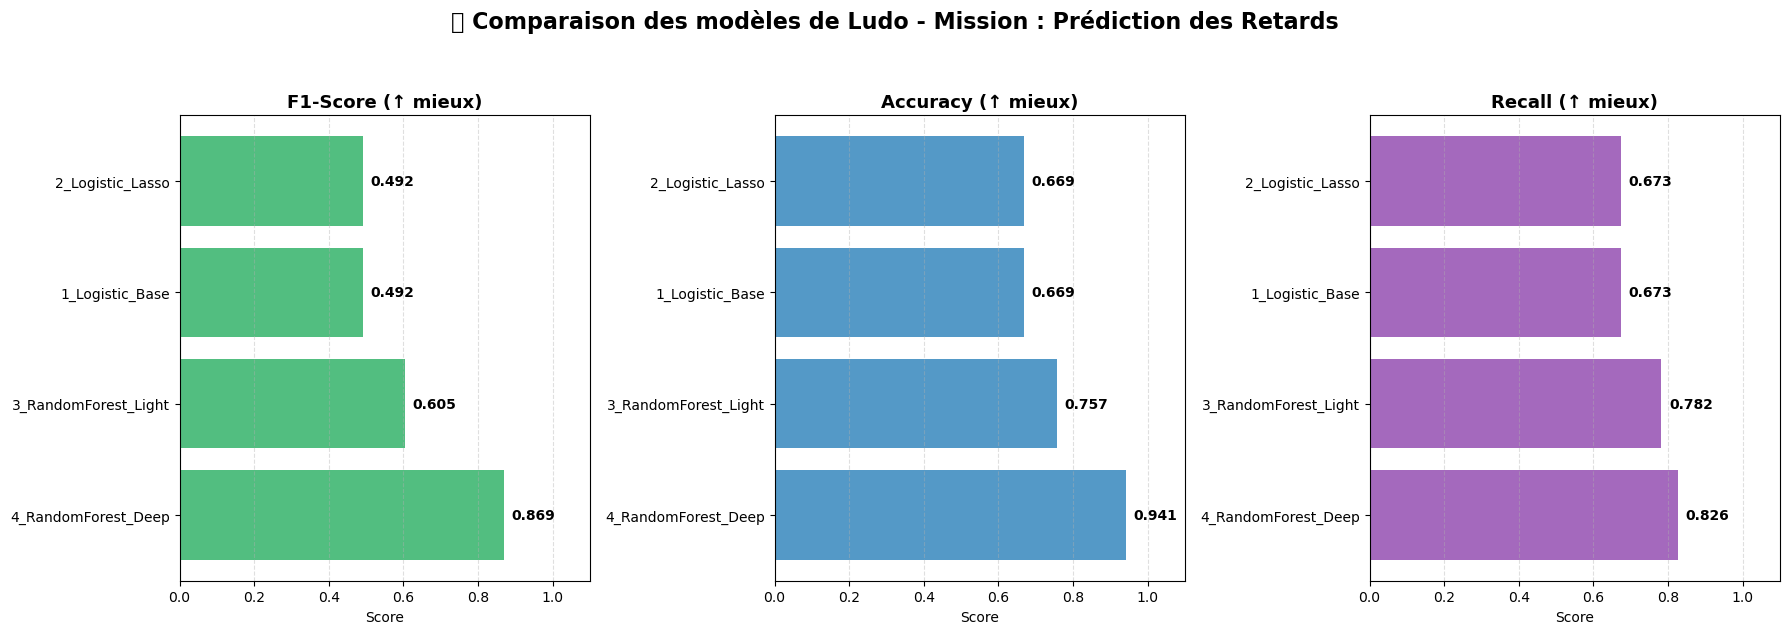

In [20]:
# =====================================================================
# VISUALISATION COMPARATIVE — VERSION CLASSIFICATION
# =====================================================================

# 1. On transforme les résultats en DataFrame et on trie par F1-Score (le plus important)
df_results = pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False)

print("--- Classement des modèles (F1-Score décroissant — meilleur en haut) ---")
print(df_results.round(4))

# 2. Configuration du graphique (3 sous-graphiques)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Liste des métriques à afficher
metrics_to_plot = [
    ('f1',       'F1-Score (↑ mieux)', '#27ae60'),  # Vert
    ('accuracy', 'Accuracy (↑ mieux)', '#2980b9'),  # Bleu
    ('recall',   'Recall (↑ mieux)',   '#8e44ad')   # Violet
]

for ax, (metric, title, color) in zip(axes, metrics_to_plot):
    # On récupère les valeurs
    vals = df_results[metric]
    
    # Création des barres horizontales
    bars = ax.barh(df_results.index, vals, color=color, alpha=0.8)
    
    # Personnalisation
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1.1)  # Les scores sont entre 0 et 1
    ax.set_xlabel('Score')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Ajout des valeurs numériques au bout des barres
    for bar, val in zip(bars, vals):
        ax.text(val + 0.02, 
                bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', 
                va='center', fontsize=10, fontweight='bold')

plt.suptitle(f"🚀 Comparaison des modèles de Ludo - Mission : Prédiction des Retards", 
             fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Optimisation du meilleur modèle (RandomizedSearchCV)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# =====================================================================
# HYPERPARAMETER TUNING — RANDOM FOREST (VERSION LUDO - CLASSIFICATION)
# =====================================================================

# 1. On définit l'espace de recherche
# Note : on utilise 'clf__' car c'est le nom de l'étape dans notre pipeline
param_distributions = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [15, 25, 35, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4],
    'clf__max_features':      ['sqrt', 'log2', 0.5],
    'clf__class_weight':      ['balanced', 'balanced_subsample']
}

# 2. Création du pipeline de tuning
rf_tuning_pipeline = Pipeline([
    ('prep', clone(preprocessor)),
    ('clf', RandomForestClassifier(n_jobs=-1, random_state=42))
])

# 3. Configuration de la recherche aléatoire
# On cherche à maximiser le F1-Score !
random_search = RandomizedSearchCV(
    rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=10,           # 10 combinaisons testées au hasard
    cv=3,                # Validation croisée sur 3 blocs
    scoring='f1',        # <--- On optimise la "Reine des métriques"
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

print("🚀 Lancement de la recherche des meilleurs réglages pour Ludo...")
random_search.fit(X_train, y_train)

# 4. Affichage des résultats
print(f"\n✨ Meilleurs paramètres trouvés :")
for k, v in random_search.best_params_.items():
    print(f"   {k:<30s}: {v}")

# 5. Évaluation et Logging du champion dans MLflow
print("\n📦 Enregistrement du modèle optimisé dans MLflow...")
res_tuned = log_model_to_mlflow(
    pipeline=random_search.best_estimator_,
    model_name="5_RandomForest_Tuned",
    X_test=X_test,
    y_test=y_test,
    extra_params=random_search.best_params_
)

print(f"\n🏆 Bilan du champion | F1: {res_tuned['f1']:.4f} | Accuracy: {res_tuned['accuracy']:.4f}")

🚀 Lancement de la recherche des meilleurs réglages pour Ludo...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


## 10. Analyse des importances de variables

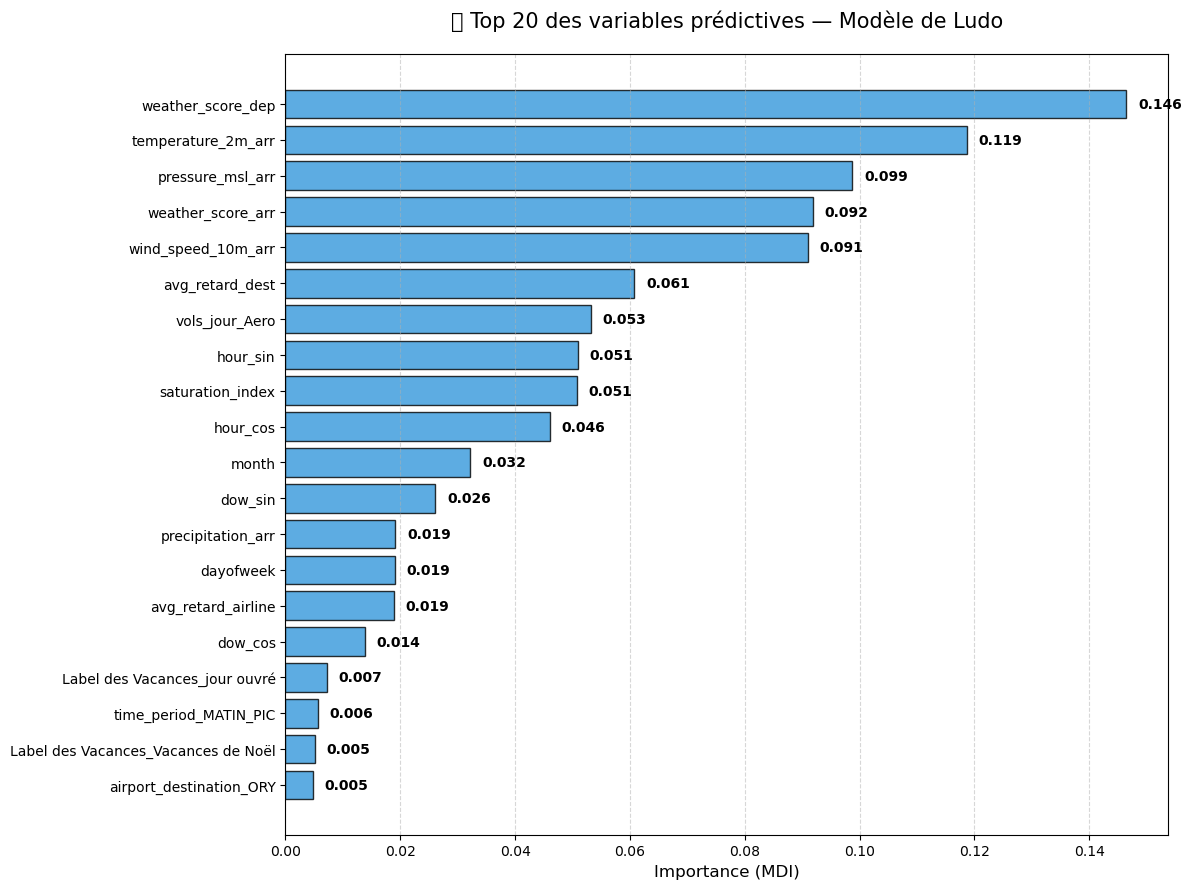


--- Top 10 des variables les plus influentes ---
           feature  importance
 weather_score_dep    0.146460
temperature_2m_arr    0.118693
  pressure_msl_arr    0.098745
 weather_score_arr    0.091794
wind_speed_10m_arr    0.090989
   avg_retard_dest    0.060775
    vols_jour_Aero    0.053168
          hour_sin    0.050972
  saturation_index    0.050716
          hour_cos    0.046091


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================================
# FEATURE IMPORTANCE — RANDOM FOREST OPTIMISÉ (LUDO)
# Méthode MDI (Mean Decrease in Impurity)
# =====================================================================

# 1. Récupération du meilleur modèle
best_model = random_search.best_estimator_

# 2. Extraction des importances
# On va chercher l'étape 'clf' (ton RandomForestClassifier)
importances = best_model.named_steps['clf'].feature_importances_

# 3. Récupération des noms de colonnes
# Puisque nous avons passé un DataFrame X au modèle, les noms sont ceux de all_features
feature_names = all_features

# 4. Création du DataFrame d'importance
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# 5. Visualisation (Top 20)
plt.figure(figsize=(12, 9))

# On inverse l'ordre pour avoir la plus importante en haut
top_20 = df_importance.head(20).iloc[::-1]

bars = plt.barh(top_20['feature'], top_20['importance'], 
                color='#3498db', edgecolor='black', alpha=0.8)

# Ajout des valeurs au bout des barres pour la précision
for bar in bars:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.3f}', va='center', fontsize=10, fontweight='bold')

plt.title(f"🏆 Top 20 des variables prédictives — Modèle de Ludo", fontsize=15, pad=20)
plt.xlabel("Importance (MDI)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Affichage textuel propre
print("\n--- Top 10 des variables les plus influentes ---")
print(df_importance.head(10).to_string(index=False))

In [ ]:
def preparer_donnees_futur(df_new):
    df = df_new.copy()
    
    # --- 1. HARMONISATION DES NOMS (Le correctif pour ton erreur) ---
    # On crée 'airline_group' à partir de 'airline' pour correspondre au modèle
    if 'airline' in df.columns:
        df['airline_group'] = df['airline']
    
    # --- 2. TRAITEMENT DES DATES ---
    df['time_dep'] = pd.to_datetime(df['time_dep'])
    df['hour'] = df['time_dep'].dt.hour
    df['dayofweek'] = df['time_dep'].dt.dayofweek
    df['month'] = df['time_dep'].dt.month
    
    # Encodage Cyclique
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # --- 3. SATURATION & MÉTÉO ---
    # On définit les pistes pour les 5 aéroports
    INFRA_Pistes = {'CDG': 4, 'ORY': 3, 'MRS': 2, 'NCE': 2, 'LYS': 2, 'TLS': 2}
    df['nb_pistes'] = df['airport_destination'].map(INFRA_Pistes).fillna(2)
    
    # Calcul de la saturation sur le flux futur
    df['vols_jour_Aero'] = df.groupby(['airport_destination', 'flight_date'])['airport_destination'].transform('count')
    df['saturation_index'] = df['vols_jour_Aero'] / df['nb_pistes']

    # Weather Score (on utilise les colonnes présentes dans ton print)
    for suffix in ['_dep', '_arr']:
        wind = f'wind_speed_10m{suffix}'
        precip = f'precipitation{suffix}'
        clouds = f'cloud_cover{suffix}'
        df[f'weather_score{suffix}'] = (
            (df[wind].fillna(0) / 50) + 
            (df[precip].fillna(0) / 10) + 
            (df[clouds].fillna(0) / 100)
        ) / 3

    # --- 4. TARGET ENCODING (Moyennes historiques) ---
    # On utilise global_mean (défini juste avant) si la compagnie est nouvelle
    df['avg_retard_airline'] = df['airline_group'].map(dict_retard_airline).fillna(global_mean)
    df['avg_retard_dest'] = df['airport_destination'].map(dict_retard_dest).fillna(global_mean)

    # --- 5. DUMMIES (One-Hot Encoding) ---
    # On transforme les catégories en colonnes 0/1
    df = pd.get_dummies(df, columns=['airport_destination', 'airline_group', 'Label des Vacances'])
    
    return df

: 

In [ ]:
# On crée les dictionnaires de référence à partir de ton dataset d'entraînement
# On utilise df_fe (ton dataset après Feature Engineering)
dict_retard_airline = df_fe.groupby('airline_group')['retard arrivée'].mean().to_dict()
dict_retard_dest = df_fe.groupby('airport_destination')['retard arrivée'].mean().to_dict()
global_mean = df_fe['retard arrivée'].mean()

In [ ]:
# S'assurer que les dictionnaires sont prêts
dict_retard_airline = df_fe.groupby('airline_group')['retard arrivée'].mean().to_dict()
dict_retard_dest = df_fe.groupby('airport_destination')['retard arrivée'].mean().to_dict()
global_mean = df_fe['retard arrivée'].mean()

# Lancer la machine
df_futur_prete = preparer_donnees_futur(df_predict)
df_futur_final = df_futur_prete.reindex(columns = X.columns, fill_value=0)

# Prédiction
preds = le_champion.predict(df_futur_final)
probs = le_champion.predict_proba(df_futur_final)[:, 1]

# Résultat final
df_resultats = df_predict.copy()
df_resultats['Prediction_Retard'] = preds
df_resultats['Confiance_Score'] = (probs * 100).round(2)

print("✅ Succès ! Voici les 5 vols les plus à risque pour Ludo :")
print(df_resultats.sort_values('Confiance_Score', ascending=False)[['flight_date', 'airline', 'airport_destination', 'Confiance_Score']].head(5))

✅ Succès ! Voici les 5 vols les plus à risque pour Ludo :
     flight_date          airline airport_destination  Confiance_Score
3339  2026-04-22          Finnair                 NCE            65.91
3403  2026-04-22  Delta Air Lines                 NCE            65.64
3650  2026-04-22    Saudi Arabian                 NCE            65.41
3559  2026-04-22    China Eastern                 NCE            65.41
3535  2026-04-22    Air Mauritius                 NCE            65.41


In [ ]:
# Affiche les 20 vols avec la plus forte probabilité de retard
df_resultats.sort_values('Confiance_Score', ascending=False).head(20)

,flight_date,movement_date,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,actual_source_departure,actual_source_arrival,arrival_delay_min,status,movement_type,time_dep,relative_humidity_2m_dep,dew_point_dep,icing_conditions_dep,rain_dep,freezing_rain_dep,snow_dep,thunderstorms_dep,pressure_msl_dep,wind_shear_dep,wind_gusts_10m_dep,wind_speed_10m_dep,wind_direction_10m_dep,precipitation_dep,has_precipitation_dep,fog_dep,humidity_dep,temperature_2m_dep,cloud_cover_dep,time_arr,relative_humidity_2m_arr,dew_point_arr,icing_conditions_arr,rain_arr,freezing_rain_arr,snow_arr,thunderstorms_arr,pressure_msl_arr,wind_shear_arr,wind_gusts_10m_arr,wind_speed_10m_arr,wind_direction_10m_arr,precipitation_arr,has_precipitation_arr,fog_arr,humidity_arr,temperature_2m_arr,cloud_cover_arr,Vacances Scolaires,Label des Vacances,Jour férié,Label Jour Ferié,Week End,Vacances PRS,Vacances NCE,Vacances TLS,Vacances MRS,Vacances LYS,is_summer_vacation,GREVE_LYON,GREVE_TOULOUSE,GREVE_NICE,GREVE_MARSEILLE,GREVE_CDG,GREVE_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée,is_weekend,Prediction_Retard,Confiance_Score
3339,2026-04-22,2026-04-22,Finnair,CDG,NCE,2F,2,0,0,0.0,Expected,departure,2026-04-22 12:00:00+00:00,33.0,-3.0,0,0.0,0,0.0,0,1018.6,26.21,41.4,21.6,28.0,0.0,0,0,33.0,12.8,100.0,2026-04-22 13:00:00+00:00,66.0,8.0,0,0.0,0,0.0,0,1006.1,10.20,20.5,9.7,75.0,0.1,1,0,66.0,14.3,96.0,"PARIS, NICE, TOULOUSE, MARSEILLE",Vacances de printemps,0.0,NaN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,2167.0,2197.0,4364.0,0.0,155.0,157.0,312.0,0.0,0.0,0,1.0,65.91
3403,2026-04-22,2026-04-22,Delta Air Lines,CDG,NCE,2F,2,0,0,0.0,Expected,departure,2026-04-22 12:00:00+00:00,33.0,-3.0,0,0.0,0,0.0,0,1018.6,26.21,41.4,21.6,28.0,0.0,0,0,33.0,12.8,100.0,2026-04-22 13:00:00+00:00,66.0,8.0,0,0.0,0,0.0,0,1006.1,10.20,20.5,9.7,75.0,0.1,1,0,66.0,14.3,96.0,"PARIS, NICE, TOULOUSE, MARSEILLE",Vacances de printemps,0.0,NaN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,2167.0,2197.0,4364.0,0.0,155.0,157.0,312.0,0.0,0.0,0,1.0,65.64
3650,2026-04-22,2026-04-22,Saudi Arabian,CDG,NCE,2F,2,0,0,0.0,Expected,departure,2026-04-22 12:00:00+00:00,33.0,-3.0,0,0.0,0,0.0,0,1018.6,26.21,41.4,21.6,28.0,0.0,0,0,33.0,12.8,100.0,2026-04-22 13:00:00+00:00,66.0,8.0,0,0.0,0,0.0,0,1006.1,10.20,20.5,9.7,75.0,0.1,1,0,66.0,14.3,96.0,"PARIS, NICE, TOULOUSE, MARSEILLE",Vacances de printemps,0.0,NaN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,2167.0,2197.0,4364.0,0.0,155.0,157.0,312.0,0.0,0.0,0,1.0,65.41
3559,2026-04-22,2026-04-22,China Eastern,CDG,NCE,2F,2,0,0,0.0,Expected,departure,2026-04-22 12:00:00+00:00,33.0,-3.0,0,0.0,0,0.0,0,1018.6,26.21,41.4,21.6,28.0,0.0,0,0,33.0,12.8,100.0,2026-04-22 13:00:00+00:00,66.0,8.0,0,0.0,0,0.0,0,1006.1,10.20,20.5,9.7,75.0,0.1,1,0,66.0,14.3,96.0,"PARIS, NICE, TOULOUSE, MARSEILLE",Vacances de printemps,0.0,NaN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,2167.0,2197.0,4364.0,0.0,155.0,157.0,312.0,0.0,0.0,0,1.0,65.41
3535,2026-04-22,2026-04-22,Air Mauritius,CDG,NCE,2F,2,0,0,0.0,Expected,departure,2026-04-22 12:00:00+00:00,33.0,-3.0,0,0.0,0,0.0,0,1018.6,26.21,41.4,21.6,28.0,0.0,0,0,33.0,12.8,100.0,2026-04-22 13:00:00+00:00,66.0,8.0,0,0.0,0,0.0,0,1006.1,10.20,20.5,9.7,75.0,0.1,1,0,66.0,14.3,96.0,"PARIS, NICE, TOULOUSE, MARSEILLE",Vacances de printemps,0.0,NaN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,2167.0,2197.0,4364.0,0.0,155.0,157.0,312.0,0.0,0.0,0,1.0,65.41
3325,2026-04-22,2026-04-22,Aerolineas Argentinas,CDG,NCE,2F,2,0,0,0.0,Expected,departure,2026-04-22 12:00:00+00:00,33.0,-3.0,0,0.0,0,0.0,0,1018.6,26.21,41.4,21.6,28.0,0.0,0,0,33.0,12.8,100.0,2026-04-22 13:00:00+00:00,66.0,8.0,0,0.0,0,0.0,0,1006.1,10.20,20.5,9.7,75.0,0.1,1,0,66.0,14.3,96.0,"PARIS, NICE, TOULOUSE, MARSEILLE",Vacances de printemps,0.0,NaN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,2167.0,2197.0,4364.0,0.0,155.0,157.0,312.0,0.0,0.

## 11. Récapitulatif final

In [ ]:
# =====================================================================
# BILAN COMPLET DU PROJET — VERSION CORRIGÉE (LUDO)
# =====================================================================

# Sécurité : on vérifie que res_tuned existe (au cas où tu n'as pas fini le tuning)
all_results = results.copy()
if 'res_tuned' in locals():
    all_results += [res_tuned]

print("=" * 80)
print(f"{'📊 BILAN FINAL — PRÉDICTION DES RETARDS AÉRIENS (LUDO)':^80}")
print("=" * 80)

# 1. Statistiques du Pipeline de Données
# On utilise df_5 qui est ton dataset après les premiers filtres
print(f"  🔹 Données Source      : {X.shape[0]:,} vols analysés") 
print(f"  🔹 Feature Engineering : {X.shape[1]} variables finales (112 colonnes)")
print(f"  🔹 Split Train / Test  : {X_train.shape[0]:,} / {X_test.shape[0]:,} lignes")
print(f"  🔹 Équilibre Cible     : {y.mean():.1%} de retards (Classe 1)")
print("-" * 80)

# 2. Tableau Comparatif des Modèles
print(f"  {'Modèle':35s} | {'F1':>6} | {'Acc':>6} | {'Prec':>6} | {'Rec':>6}")
print(f"  {'-'*75}")

# On trie par F1-Score décroissant
for r in sorted(all_results, key=lambda x: x.get('f1', 0), reverse=True):
    name = r.get('model', 'N/A')
    f1   = r.get('f1', 0)
    acc  = r.get('accuracy', 0)
    prec = r.get('precision', 0)
    rec  = r.get('recall', 0)
    
    print(f"  {name:35s} | {f1:6.3f} | {acc:6.3f} | {prec:6.3f} | {rec:6.3f}")

print("-" * 80)

# 3. Accès aux Expériences
print(f"  🌐 Serveur MLflow      : {MLFLOW_REMOTE_URI}")
print(f"  👤 Auteur du projet    : Ludo - Manjakasoa - Patrick - Philippe Cabrel")
print("=" * 80)

NameError: name 'results' is not defined